# Downsampling alignment of E145 and E165 by FsGW_relative

In [1]:
import os
from scipy.spatial import distance
from pathlib import Path
from tqdm import tqdm
import torch
import pandas as pd
import numpy as np
import scanpy as sc
from raftup import (
    _downsample,
    _fsgw_utils,
    _metrics_two_gpr,
    _load_data,
    _plot,
    _recoverfull_new_new_knn
)


/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/anaconda3/envs/raftup/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Each downsampeld subslice contains 100 spots and we adopt the data and feature cost C in SpaTrack.

In [2]:
random_state = 23
np.random.seed(random_state)
ds_pts = 100

adata_all = sc.read_h5ad('../data/04.mouse.midbrain.three.time.point.ST.exp.h5ad')

sliceA=adata_all[adata_all.obs['Time point']=='E14.5']
sliceB=adata_all[adata_all.obs['Time point']=='E16.5']
adata_all.uns['annotation_colors']=['#9A154C', '#F3754E', '#5B58A7']

pair = "E145E165"

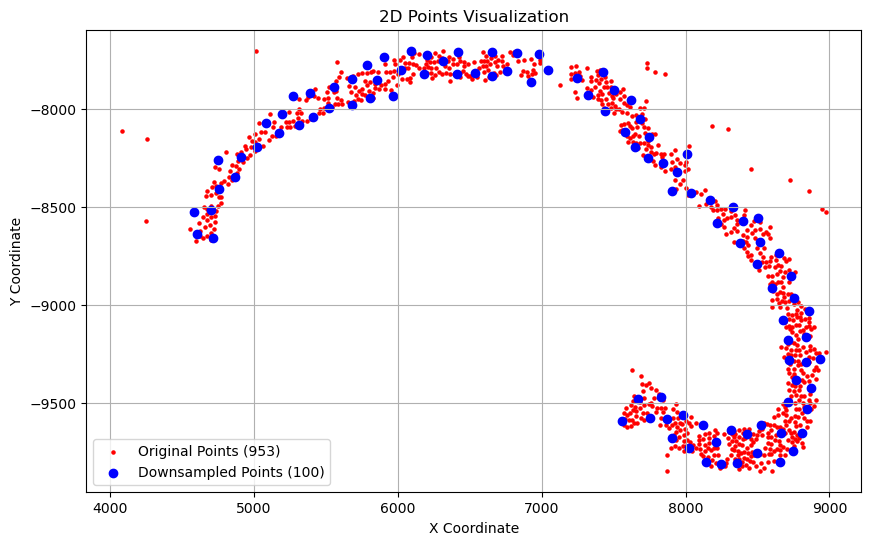

In [3]:
downsampled_sliceA,indices_dsa, _= _downsample.robust_maxmin_downsample_slice(sliceA, ds_pts,outlier_fraction=0.05, n_neighbors=20)
_downsample.visualize_downsampled_points(sliceA, downsampled_sliceA)

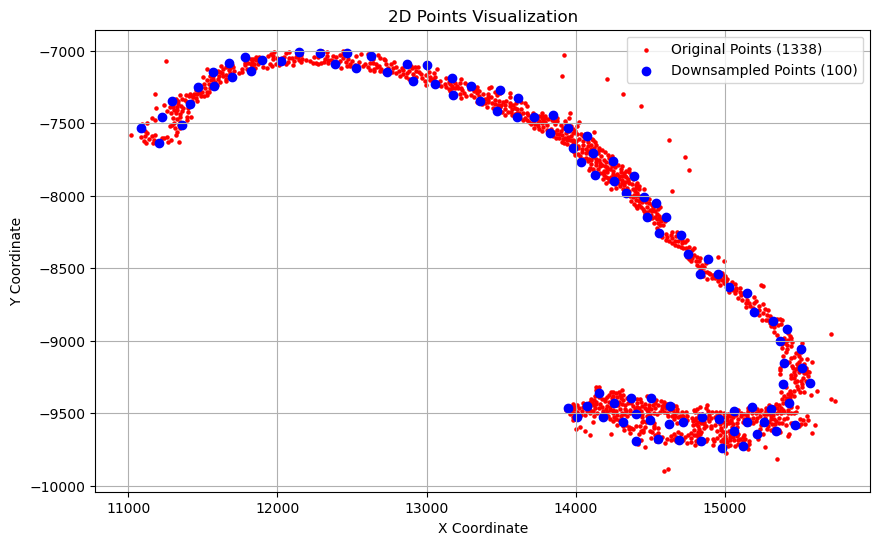

In [4]:
downsampled_sliceB,indices_dsb, _= _downsample.robust_maxmin_downsample_slice(sliceB, ds_pts)
_downsample.visualize_downsampled_points(sliceB, downsampled_sliceB)

In [5]:
file_path = "./feature_matrix_23.csv"
M = _fsgw_utils.extract_feature_matrix(file_path, indices_dsa, indices_dsb)

After rescaling: min = 0.6456484610146159, max = 1.0.


In [6]:
D_A_test = distance.cdist(downsampled_sliceA.obsm['spatial'], downsampled_sliceA.obsm['spatial'])
D_B_test = distance.cdist(downsampled_sliceB.obsm['spatial'], downsampled_sliceB.obsm['spatial'])

testA = D_A_test[D_A_test>0]
testB = D_B_test[D_B_test>0]
print(np.min(testA),np.max(testA), np.min(testB), np.max(testB))

96.56603957913983 4411.7363928503255 93.50935782048552 4836.09480883078


# Compute FsGW_relative with \rho_{f_1} = 0.95 and \rho_{s} = 6.5

Running different GW cutoffs:   0%|          | 0/1 [00:00<?, ?it/s]


Running GW cutoff = 6.5, CC cutoff = 0.95


Finding min vertex covering for gw_cutoff_ratio 6.5 and cutoff_CC 0.95: 100%|██████████| 6371580/6371580 [00:50<00:00, 126473.83it/s]


# of potential non-zeros in P: 87


Running different GW cutoffs: 100%|██████████| 1/1 [02:40<00:00, 160.06s/it]


P.sum(): 0.8699999999999823
Saved to: align_data/ds_matching_E145E165_6.5_0.95_relative.csv


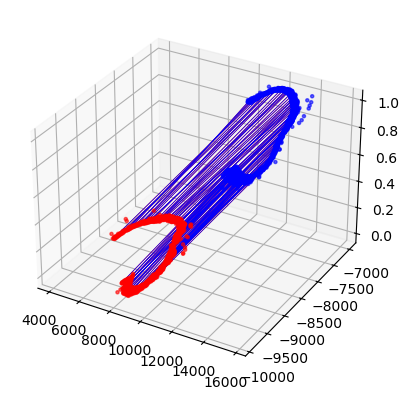

In [7]:
gw_ratio_list = [6.5]
cutoff_CC = 0.95
save_folder = "align_data"
os.makedirs(save_folder, exist_ok=True)

for gw_ratio in tqdm(gw_ratio_list, desc="Running different GW cutoffs"):
    print(f"\nRunning GW cutoff = {gw_ratio}, CC cutoff = {cutoff_CC}")

    P = _fsgw_utils.fsgw_mvc_relative(D_A_test, D_B_test, M, gw_cutoff_ratio=gw_ratio, w_cutoff=cutoff_CC)

    L_sig, L_full, indices_A_matched, indices_B_matched= _recoverfull_new_new_knn.generate_binary_matching_relative(sliceA, downsampled_sliceA, sliceB, downsampled_sliceB, P, save_folder)
    _plot.plot_3d(sliceA.obsm['spatial'], sliceB.obsm['spatial'], L_sig, indices_A_matched, indices_B_matched, linewidth=0.5)
    
    print("P.sum():", P.sum())

    save_path = os.path.join(save_folder, f"ds_matching_{pair}_{gw_ratio}_{cutoff_CC}_relative.csv")
    np.savetxt(save_path, P, delimiter=",", fmt='%.8f')

    print(f"Saved to: {save_path}")